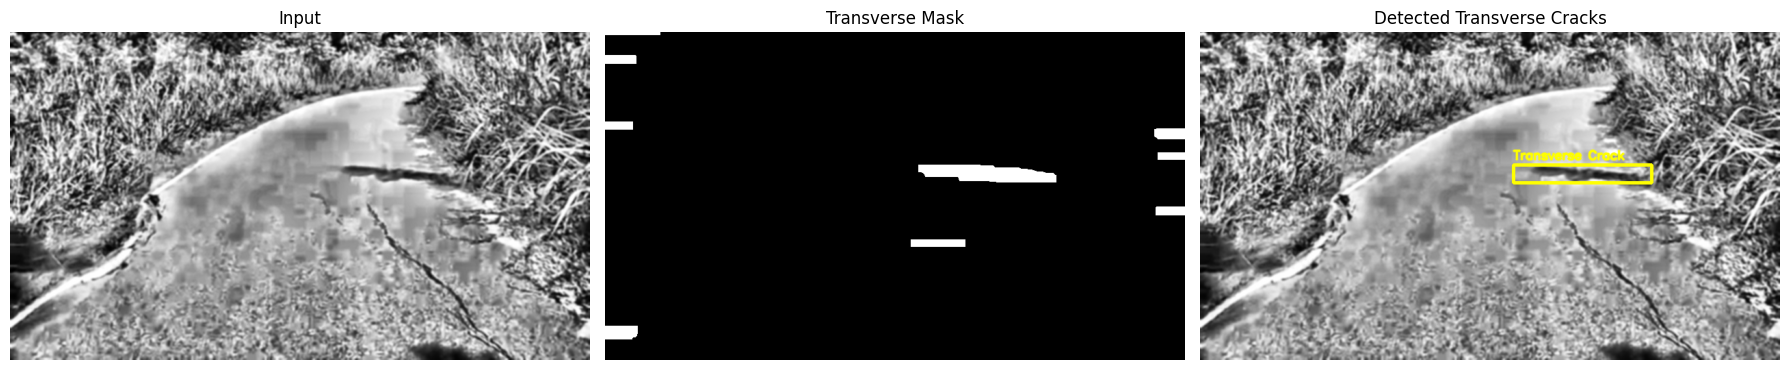

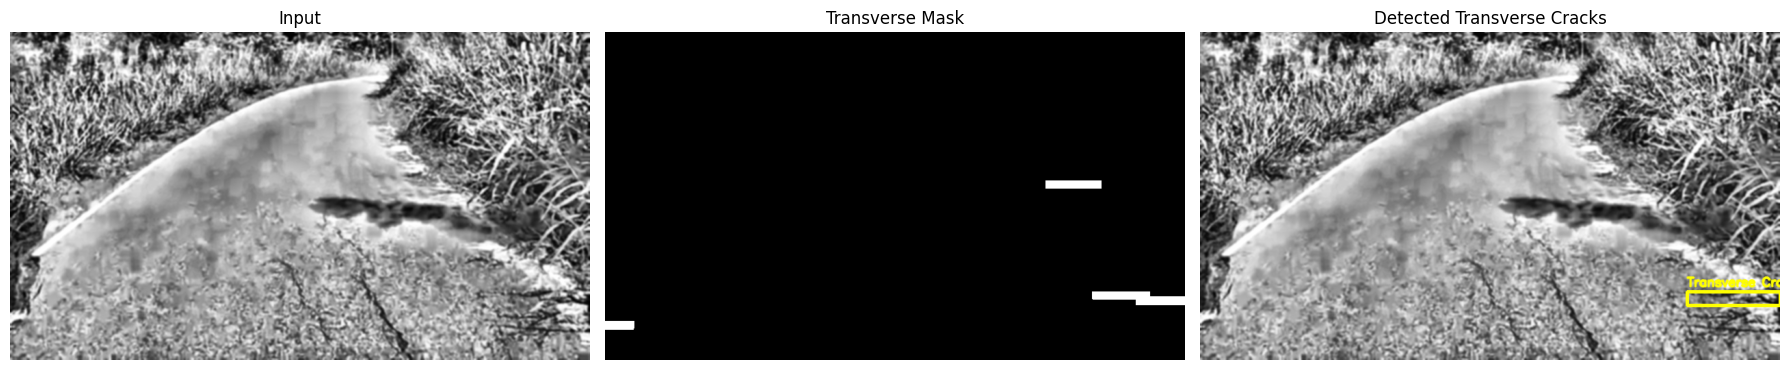

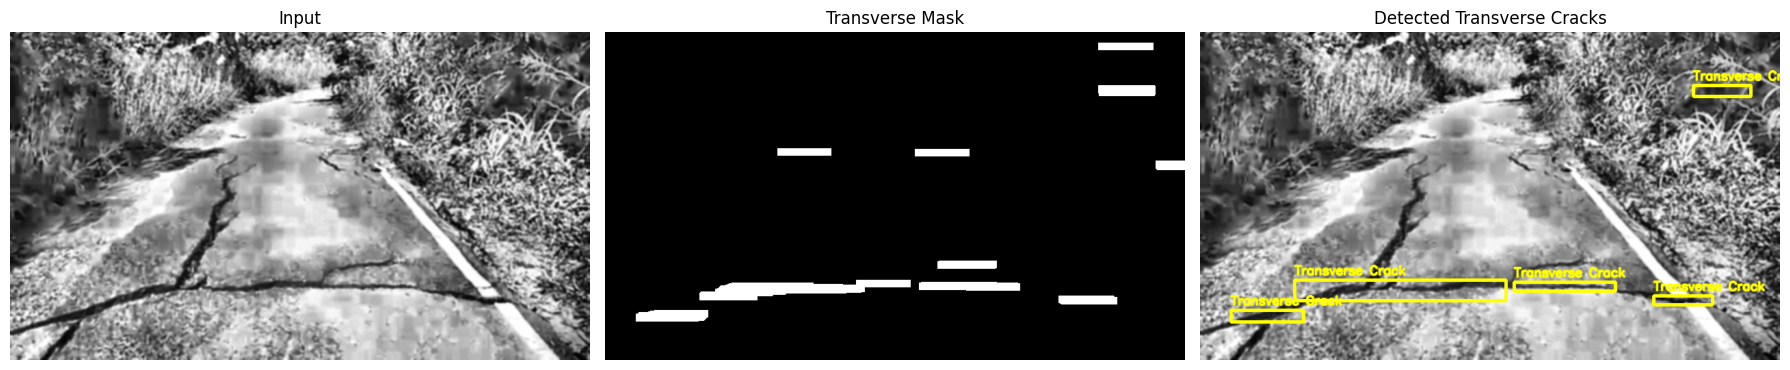

Transverse crack detection completed!


In [1]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

# Folder structure
input_folder = "../../frames/enhanced/4_FinalEnhanced/TransverseCracking"
output_folder = "../../frames/segmented/TransverseCracking"

os.makedirs(output_folder, exist_ok=True)

max_show = 3
count = 0

# Transverse extraction function
def extract_transverse(gray):

    # CLAHE
    clahe = cv2.createCLAHE(
        clipLimit=2.5,
        tileGridSize=(8, 8)
    )

    enhanced = clahe.apply(gray)

    # Blur
    blur = cv2.GaussianBlur(enhanced, (5, 5), 0)

    # Dark cracks become bright
    blackhat_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (21, 21)
    )

    blackhat = cv2.morphologyEx(
        blur,
        cv2.MORPH_BLACKHAT,
        blackhat_kernel
    )

    # Treshold
    _, binary = cv2.threshold(
        blackhat,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # Remove small noise
    binary = cv2.morphologyEx(
        binary,
        cv2.MORPH_OPEN,
        np.ones((3, 3), np.uint8),
        iterations=1
    )

    # Horizontal extraction 
    horizontal_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (45, 5)
    )

    horizontal = cv2.morphologyEx(
        binary,
        cv2.MORPH_OPEN,
        horizontal_kernel
    )

    # Merge nearby horizontal parts
    merge_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (35, 7)
    )

    merged = cv2.dilate(
        horizontal,
        merge_kernel,
        iterations=1
    )

    merged = cv2.morphologyEx(
        merged,
        cv2.MORPH_CLOSE,
        np.ones((9, 9), np.uint8),
        iterations=1
    )

    return merged

# Detect transverse crack regions
def detect_transverse(image, mask):

    output = image.copy()

    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    H, W = image.shape[:2]

    for c in contours:

        area = cv2.contourArea(c)

        # Remove small regions
        if area < 1000:
            continue

        x, y, w, h = cv2.boundingRect(c)

        if w < 80:
            continue

        # Aspect ratio
        aspect_ratio = w / (h + 1e-5)

        if aspect_ratio < 2.5:
            continue

        # Draw detected transverse crack
        cv2.rectangle(
            output,
            (x, y),
            (x + w, y + h),
            (0, 255, 255),
            3
        )

        cv2.putText(
            output,
            "Transverse Crack",
            (x, y - 8),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 255),
            2,
            cv2.LINE_AA
        )

    return output


# Main processing loop
if not os.path.isdir(input_folder):
    print(f"Input folder does not exist: {input_folder}")
else:
    for file in os.listdir(input_folder):

        if file.lower().endswith((".jpg", ".png", ".jpeg")):

            path = os.path.join(input_folder, file)

            img = cv2.imread(path)

            if img is None:
                continue

            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            mask = extract_transverse(gray)

            result = detect_transverse(img, mask)

            # Save output
            save_path = os.path.join(output_folder, file)
            cv2.imwrite(save_path, result)

            # Visualization
            if count < max_show:

                plt.figure(figsize=(18, 6))

                plt.subplot(1, 3, 1)
                plt.imshow(gray, cmap="gray")
                plt.title("Input")
                plt.axis("off")

                plt.subplot(1, 3, 2)
                plt.imshow(mask, cmap="gray")
                plt.title("Transverse Mask")
                plt.axis("off")

                plt.subplot(1, 3, 3)
                plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
                plt.title("Detected Transverse Cracks")
                plt.axis("off")

                plt.tight_layout()
                plt.show()

                count += 1

print("Transverse crack detection completed!")